In [31]:
# Capstone -- function 7 (6D)

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.spatial import Delaunay, ConvexHull
from scipy.stats import spearmanr

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 7

6D, 34 observations (30 initial + weeks 2–5). Domain is the unit cube `[0,1]^6`.

Week 5 (`y = 1.434055`, at `[0.044754, 0.491672, 0.247422, 0.197315, 0.394860, 0.719635]`) is the new incumbent, edging out week 3 by 0.06. Propose with **UCB, `kappa = 0.5`**, over the live axes `{x0, x3, x4, x5}`, holding x1/x2 at the incumbent — the largest kappa whose predicted mean still beats the incumbent (see "Choosing kappa" below).

## x1, x2 are settled

Three independent checks agree they carry no signal: the initial design sweeps both fully (not one line), model-free pairing shows no difference in mean |Δy| between near/far x1–x2 pairs, and the GP's own mean-variation on them is 33–275× smaller than the live axes, with both length-scales pinned or near-pinned. Held at the incumbent.

## Choosing kappa

Restricted to the live axes, predicted mean against the incumbent (1.434055):

| kappa | pred. mean | gain |
|---|---|---|
| 0 | +1.44321 | +0.0092 |
| 0.25 | +1.44168 | +0.0076 |
| **0.5** | **+1.43578** | **+0.0017** |
| 1.0 | +1.41194 | −0.0221 |
| 2.0 | +1.32235 | −0.1117 |

Largest kappa still showing a gain is 0.5 (same criterion as functions 6 and 8). The margin is thin — well inside the ±0.037 predicted std — so this is a mild lean towards exploration, not a strong signal. No bound contact, no extrapolation.

The backtest disagrees more sharply than before: `exploit` now beats every alternative by 2.5+ s.e., not the noise-level gaps seen in prior weeks. It stays a weak input, not the decider — it's structurally biased towards exploitation (see CLAUDE.md) — but worth watching if next week's result comes back below the incumbent.

## Notes

- No y-scaling: `kappa` is dimensionless.
- The week-2 point (out of domain on 4/6 axes) stays in the fit; length-scales move only 0.98–1.06× with or without it.
- Convex hull is near-vacuous at D=6 (33/34 points are vertices) — per-axis and edge checks carry the weight instead.
- LOO: 29/34 inside their own 95% interval; worst-predicted is an initial-batch point (index 3, −5.0σ), not the incumbent.
- `plot_2d_bo` doesn't apply at D=6 — use `plot_nd_slices`. `compute_iteration_diagnostics` needs `domain_grid_n` lowered, or the default builds a 4.1e9-point grid.

In [32]:
X_initial = np.load("initial_data/function_7/initial_inputs.npy")
y_initial = np.load("initial_data/function_7/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 6, f"Expected a 6D problem, got {D}D input -- check the loaded file."

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week.

In [33]:
# My collected observations, from weekly_data/function_7/. I run
# record_results.py before opening this notebook so the results are already
# there. pending_X holds a proposal with no result yet; it never reaches the
# model.
#
# Provenance, oldest first:
#   - week 2 -- out of domain on 4/6 axes (bounds built without lower_limit=0.0
#       at the time); worst y on record.
#   - week 3 -- back inside the data cloud.
#   - week 4 -- 0.015 from week 3, confirming rather than beating it.
#   - week 5 -- 0.021 from week 3, the new incumbent.

new_X, new_y, pending_X = load_collected(7, D)

# Label each row by its own week. This used to print new_y[-1] as "week 3",
# which was right when there was one collected row and silently wrong once
# there were three.
print("observations collected so far:", len(new_y))
_running = y_initial.max()
for r, v in enumerate(new_y):
    tag = "   <- a new best" if v > _running else ""
    print("  week %d y: %.9f%s" % (r + 2, v, tag))
    _running = max(_running, v)
print("best on record: %.6f (the initial batch alone reached %.6f)"
      % (max(y_initial.max(), new_y.max()), y_initial.max()))

weekly store: 4 resulted observation(s), 1 pending proposal [0.086784 0.491672 0.247422 0.155339 0.378564 0.717258]
  NOTE the pending row will be REPLACED when this notebook saves its proposal
observations collected so far: 4
  week 2 y: 0.000308588
  week 3 y: 1.374343402   <- a new best
  week 4 y: 1.327096049
  week 5 y: 1.434054541   <- a new best
best on record: 1.434055 (the initial batch alone reached 1.364968)


## Build the full dataset (initial + everything collected so far)

In [34]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| combined X shape:", X.shape)
print("y range: %.9f to %.6f (spread %.6f, std %.6f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))
for r in range(len(new_y)):
    print("rank of the week-%d observation: %d of %d (1 = best)"
          % (r + 2, int((y > new_y[r]).sum()) + 1, len(y)))

# The domain is the unit cube, so bounds are [0,1] on every axis. lower_limit
# is load-bearing here specifically: without it this function's padded bounds
# went below zero, and my week-2 sweep duly proposed a negative coordinate.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
# Week 2 went above 1 before I knew the domain, so it sits outside these bounds.
# I validate the in-domain subset -- catching bounds too narrow for the data is
# what validate_bounds_consistency is for -- and report the rest rather than
# dying on it.
_in_dom = np.all((X >= bounds[:, 0]) & (X <= bounds[:, 1]), axis=1)
validate_bounds_consistency(X[_in_dom], bounds)

if not _in_dom.all():
    print(f"\n{int((~_in_dom).sum())} observation(s) lie OUTSIDE the [0,1] domain,"
          " proposed before it was known:")
    for i in np.flatnonzero(~_in_dom):
        over = [f"x{d}={X[i, d]:.4f}" for d in range(D) if X[i, d] > 1.0]
        print(f"  {', '.join(over)}   y={y[i]:+.5g}")
    print("  It stays IN the fit: its y is ordinary rather than a spurious record,")
    print("  and it barely touches the kernel (see the length-scale ratios below).")
    print("  The search is clamped to [0,1] regardless, so nothing can be proposed")
    print("  out there again.")
print("\nBounds:\n", np.round(bounds, 4))

# How far outside the sampled region did each proposal reach? Week 2 is the
# evidence that extrapolation does not pay on this function; week 3 stayed
# inside and came back the best on record, which reinforces it.
print("\ncollected points vs the INITIAL batch's range:")
n_out_by_week = []
for r in range(len(new_X)):
    n_out = 0
    for d in range(D):
        outside = (new_X[r, d] > X_initial[:, d].max()
                   or new_X[r, d] < X_initial[:, d].min())
        n_out += outside
        print(f"  week {r + 2}  x{d}={new_X[r, d]:.6f}  initial range"
              f" [{X_initial[:, d].min():.4f}, {X_initial[:, d].max():.4f}]"
              f"  outside={outside}")
    n_out_by_week.append(n_out)
    print(f"  -> week {r + 2}: {n_out} of {D} coordinates were extrapolations,"
          f" y={new_y[r]:+.9f}")
# Index the best week rather than assuming it is the last row -- week 4 is the
# last row and it did NOT return the best.
_worst_wk = int(np.argmin(new_y))
_best_wk = int(np.argmax(new_y))
print("-> week %d extrapolated on %d of %d axes and returned the worst y on record;"
      " week %d extrapolated on %d and returned the best."
      % (_worst_wk + 2, n_out_by_week[_worst_wk], D,
         _best_wk + 2, n_out_by_week[_best_wk]))

try:
    hull = Delaunay(X)
    ch = ConvexHull(X)
    box_volume = float(np.prod(X.max(axis=0) - X.min(axis=0)))
    print(f"\nobserved box volume {box_volume:.4g} | convex hull {ch.volume:.4g}"
          f" ({ch.volume / box_volume:.2%} of it)")
    print(f"{len(ch.vertices)} of {len(X)} observations are hull vertices"
          " -- at D=6 almost all are, so the hull test is nearly vacuous here")
except Exception as exc:
    hull = None
    print("\nconvex hull unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.4%} of the y spread"
      f" -> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")
print("(kappa is dimensionless, so UCB is unaffected either way)")

X_initial shape: (30, 6) | combined X shape: (34, 6)
y range: 0.000308588 to 1.434055 (spread 1.433746, std 0.437551)
rank of the week-2 observation: 34 of 34 (1 = best)
rank of the week-3 observation: 2 of 34 (1 = best)
rank of the week-4 observation: 4 of 34 (1 = best)
rank of the week-5 observation: 1 of 34 (1 = best)

1 observation(s) lie OUTSIDE the [0,1] domain, proposed before it was known:
  x1=1.1104, x2=1.0474, x3=1.6675, x5=1.1193   y=+0.00030859
  It stays IN the fit: its y is ordinary rather than a spurious record,
  and it barely touches the kernel (see the length-scale ratios below).
  The search is clamped to [0,1] regardless, so nothing can be proposed
  out there again.

Bounds:
 [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]

collected points vs the INITIAL batch's range:
  week 2  x0=0.273698  initial range [0.0579, 0.9425]  outside=False
  week 2  x1=1.110420  initial range [0.0118, 0.9247]  outside=True
  week 2  x2=1.047450  initial range [0.0036, 0.9246]

## Is the model stable and calibrated?

Two checks.

First, refit on the initial batch alone and predict each collected point. That fit never saw them, so this is a genuine out-of-sample test. All three land inside 1 sigma — including week 2, where the model correctly expected a mediocre value, so the failure that week was my *proposal*, not the surrogate. That is what lets me lean on its posterior mean now.

Second, compare kernels before and after. A length-scale reshaped by one observation would make every variance-driven acquisition untrustworthy. Here they move by 0.98–1.06× and the same two axes stay pinned before and after, so the verdict is stable.

In [35]:
# Both fits first, in one block, so no ConvergenceWarning can land between the
# rows printed below. Two separate blocks here printed two identical reports.
with fitting("before/after fits for the collected observations"):
    gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25,
                       random_state=0)
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)

# Fit is the initial batch only, so every collected row is genuinely out of
# sample. The model that actually proposed week 3 also had week 2, so for the
# later rows this understates what was known at proposal time.
mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
print("out-of-sample test on the collected points (fit = initial batch only):")
for r in range(len(new_X)):
    miss = new_y[r] - mu_b[r]
    print(f"  week {r + 2}: predicted {mu_b[r]:+.6f} +/- {sd_b[r]:.6f}"
          f"   actual {new_y[r]:+.9f}")
    print(f"    miss {miss:+.6f} = {miss / sd_b[r]:+.1f} sigma"
          f"  -> {'well calibrated' if abs(miss / sd_b[r]) < 3 else 'POORLY calibrated'}")
print("  (week 2 read) the model expected a mediocre value there: the proposal")
print("  was the problem, not the surrogate, so its posterior mean is usable.")

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)
print("\nlength-scales before:", np.round(ls_before, 4))
print("length-scales after :", np.round(ls_after, 4))
print("ratio (after/before):", np.round(ls_after / ls_before, 3))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")
print("-> the same axes are pinned before and after, so that verdict is stable")

_move = float(np.max(np.abs(ls_after / ls_before - 1)))
print("largest length-scale move: %.0f%%" % (100 * _move))
if _move > 0.5:
    print("\n*** A length-scale moved by more than 50% across the collected")
    print("    observations. Treat variance-driven acquisitions with suspicion. ***")


[fitting: before/after fits for the collected observations] 4 warnings held back, 3 distinct:
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
out-of-sample test on the collected points (fit = initial batch only):
  week 2: predicted +0.205674 +/- 0.315736   actual +0.000308588
    miss -0.205366 = -0.7 sigma  -> well calibrated
  week 3: predicted +1.373747 +/- 0.053455   actual +1.374343402
    miss +0.000597 = +0.0 sigma  -> well calibrated
  week 4: predicted +1.372550 +/- 0.044418   actual +1.327096049
    miss -0.045454 = -1.0 sigma  -> well calibrated
  week 5: predicted +1.364253 +/- 0.059896   actual +1.434054541
    miss +0.069801 = +1.2 sigma  -> well calibrated
  (week 2 read) the model expected a mediocre value there: the proposal
  was the problem, not the surrogate, so 

## Which axes matter

Length-scales alone aren't sufficient. A length-scale pinned at the 10.0 ceiling means "smooth, nearly linear across this domain", which is not the same as "no effect" — a mild monotone trend can still be there, and if it is, pushing along that axis is a real prediction rather than an optimiser artefact.

So the cell measures GP mean-variation directly, alongside model-free rank correlations, and then applies my flat-axis rule: flat if mean-variation is under 5% of the largest, **or** the length-scale is pinned near the ceiling.

x1 and x2 come back flat on *both* grounds — pinned at the ceiling, and moving the mean **275×** less than the largest axis — which makes this an unusually clear call. Flat axes get held at the incumbent, because a flat acquisition surface makes their coordinates optimiser artefacts.

Note that x1 and x2 still have non-zero rank correlations (−0.107 and +0.148) despite being flat. Not a contradiction: with 33 points in 6D, correlations that small are unremarkable noise, and the GP's own sweep is the more direct measure of whether moving an axis changes the prediction.

In [36]:
incumbent = X[np.argmax(y)]

# Every sweep first, then print, so the comparisons below always see the full
# set of spans rather than a running maximum.
spans = np.zeros(D)       # mean-variation over the full domain
spans_obs = np.zeros(D)   # mean-variation over the observed range only
srho = np.zeros(D)        # Spearman rank correlation with y
for d in range(D):
    for col, (lo, hi) in enumerate([(bounds[d, 0], bounds[d, 1]),
                                    (X[:, d].min(), X[:, d].max())]):
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        (spans if col == 0 else spans_obs)[d] = m.max() - m.min()
    srho[d] = spearmanr(X[:, d], y)[0]

print("incumbent (best observed):", np.round(incumbent, 6), " y = %.6f" % y.max())
print("\n%3s | %17s | %15s | %10s | %9s"
      % ("ax", "GP mean-variation", "same, observed", "len-scale", "spearman"))
for d in range(D):
    print("%3d | %17.4g | %15.4g | %10.4f | %+9.3f"
          % (d, spans[d], spans_obs[d], ls_after[d], srho[d]))

FLAT_FRAC = 0.05
flat = [d for d in range(D)
        if spans[d] < FLAT_FRAC * spans.max() or ls_after[d] >= 0.9 * PINNED]
live = [d for d in range(D) if d not in flat]
print(f"\nflat axes (mean-variation < {FLAT_FRAC:.0%} of max, or length-scale >= {0.9 * PINNED}):",
      flat or "none")
print("axes searched:", live)
if flat:
    print("the flat axes move the mean %.0fx less than the largest"
          % (spans.max() / max(spans[flat].max(), 1e-12)))
order = np.argsort(spans)[::-1]
print("dominance among the live axes: x%d is only %.1fx the next (x%d)"
      % (order[0], spans[order[0]] / spans[order[1]], order[1]))
# A monotone axis whose best end is a domain bound will put the proposal ON that
# bound. That is the model agreeing with the data, not a defect, so I flag it
# here to keep it apart from the optimiser stopping at an arbitrary edge.
for d in range(D):
    if abs(srho[d]) > 0.4:
        which = "LOWER" if srho[d] < 0 else "UPPER"
        print(f"  x{d} is monotone (spearman {srho[d]:+.3f}): its best end is the"
              f" {which} domain bound, so a proposal sitting there is expected")

print("-> no single dominant axis, so I do not reduce this to a 1D search")

incumbent (best observed): [0.044754 0.491672 0.247422 0.197315 0.39486  0.719635]  y = 1.434055

 ax | GP mean-variation |  same, observed |  len-scale |  spearman
  0 |            0.6562 |            0.61 |     0.9590 |    -0.420
  1 |           0.04315 |         0.06075 |     2.8414 |    -0.078
  2 |          0.005848 |        0.006638 |    10.0000 |    +0.125
  3 |             1.106 |           1.182 |     0.4607 |    -0.255
  4 |             1.412 |           1.412 |     0.2116 |    -0.424
  5 |             1.286 |           1.286 |     0.1284 |    +0.205

flat axes (mean-variation < 5% of max, or length-scale >= 9.0): [1, 2]
axes searched: [0, 3, 4, 5]
the flat axes move the mean 33x less than the largest
dominance among the live axes: x4 is only 1.1x the next (x5)
  x0 is monotone (spearman -0.420): its best end is the LOWER domain bound, so a proposal sitting there is expected
  x4 is monotone (spearman -0.424): its best end is the LOWER domain bound, so a proposal sitting ther

## Backtest (using only data already collected)

Structurally biased towards exploitation — it scores recognition of already-known points, which rewards ranking by posterior mean and gives no credit for reducing uncertainty. One weak input, not the decider.

This week it separates more cleanly than before: `exploit` beats every alternative, including `ucb_k0.5`, by 2.5+ s.e. — not the noise-level gaps of prior weeks. That's the tension with the kappa choice below; flagged there rather than resolved here.

xi for the PI/EI rows: 0.014337 (1% of the y spread)

is xi a live dial? (proposal movement as xi grows)
[fitting: ei at xi=0.1% of spread] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
  ei xi=  0.1% of spread: pred mean +1.4117
[fitting: ei at xi=5.0% of spread] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
  ei xi=  5.0% of spread: pred mean +1.3584  moved 0.1799
[fitting: ei at xi=100.0% of spread] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
  ei xi=100.0% of spread: pred mean +0.3778  moved 1.4535
[fitting: pi at xi=0.1

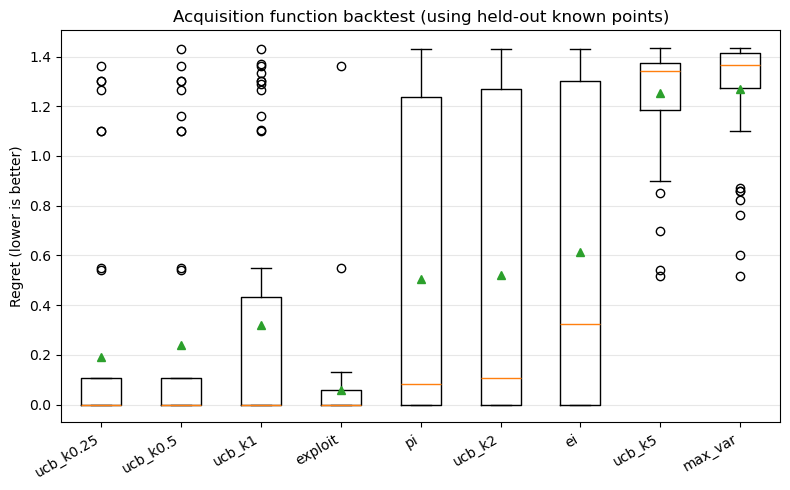

In [37]:
xi_raw = 0.01 * (y.max() - y.min())
backtest_configs = [
    {"name": "ucb_k0.25", "acquisition": "ucb", "kappa": 0.25},
    {"name": "ucb_k0.5", "acquisition": "ucb", "kappa": 0.5},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei",       "acquisition": "ei",  "xi": xi_raw},
    {"name": "pi",       "acquisition": "pi",  "xi": xi_raw},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]
print(f"xi for the PI/EI rows: {xi_raw:.6f} (1% of the y spread)")

# Is xi a live dial here, or degenerate? Checked rather than assumed.
print("\nis xi a live dial? (proposal movement as xi grows)")
_prev = {}
for _acq in ("ei", "pi"):
    for _frac in (0.001, 0.05, 1.0):
        _xi = _frac * (y.max() - y.min())
        with fitting(f"{_acq} at xi={_frac:.1%} of spread"):
            _p, _ = generate_next_point(X, y, bounds, acquisition=_acq, xi=_xi,
                                        maximize=True, n_restarts=40, random_state=0)
        _m, _ = gp_check.predict(normalize(_p.reshape(1, -1), bounds), return_std=True)
        _mv = "" if _acq not in _prev else f"  moved {np.linalg.norm(_p - _prev[_acq]):.4f}"
        print(f"  {_acq} xi={_frac:>6.1%} of spread: pred mean {_m[0]:+.4f}{_mv}")
        _prev[_acq] = _p
print("  -> xi IS live here, but both families degrade the predicted mean, so they")
print("     are variance-seeking on this function rather than degenerate.\n")

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

# Which acquisition looks best so far. Configs are compared PAIRED on the same
# splits, so "within noise" below means |mean difference| <= 2 standard errors --
# plain arithmetic, no statistical test. Read it knowing the metric scores
# RECOGNITION of points whose y is already known, which is an exploitation task.
CHOSEN = "ucb_k0.5"        # must name the committed KAPPA; asserted where KAPPA is set

assert CHOSEN in backtest_results, (
    f"{CHOSEN!r} is not among the backtest configs, so the committed setting is "
    f"never scored. Add a row for it. Have: {sorted(backtest_results)}"
)

names = list(backtest_results)
mean_r = {k: float(backtest_results[k]["regret"].mean()) for k in names}
med_r = {k: float(np.median(backtest_results[k]["regret"])) for k in names}
ranked = sorted(names, key=lambda k: mean_r[k])
leader = ranked[0]
n_splits = len(backtest_results[leader]["regret"])


def paired_gap(a, b):
    """Mean per-split regret difference (b - a), and its standard error."""
    d = backtest_results[b]["regret"] - backtest_results[a]["regret"]
    return float(d.mean()), float(d.std(ddof=1) / np.sqrt(len(d)))


tied = [k for k in ranked[1:]
        if abs(paired_gap(leader, k)[0]) <= 2 * paired_gap(leader, k)[1]]
worse = [k for k in ranked[1:] if k not in tied]

print("\n=== which acquisition appears best in our tests so far? ===")
print(f"leader by mean regret   : {leader:>10}  ({mean_r[leader]:.4f})")
best_med = min(names, key=lambda k: med_r[k])
print(f"leader by median regret : {best_med:>10}  ({med_r[best_med]:.4f})"
      + ("   (agrees)" if best_med == leader else "   (DISAGREES with the mean)"))

print(f"\npaired against {leader}, over the same {n_splits} splits:")
for k in ranked[1:]:
    gap, se = paired_gap(leader, k)
    print(f"  {k:>10}: {gap:+.4f} +/- {se:.4f} ({gap / se:>5.1f} s.e.)"
          f"   {'within noise' if k in tied else 'clearly worse'}")

print(f"\nindistinguishable from the leader : {', '.join([leader] + tied)}")
print(f"clearly worse                     : {', '.join(worse) or 'none'}")

rank = ranked.index(CHOSEN) + 1
gap, se = paired_gap(leader, CHOSEN)
print(f"\nthis notebook proposes with {CHOSEN}: ranked {rank} of {len(ranked)}", end="")
if CHOSEN == leader:
    print(" -- it leads.")
else:
    print(f", {gap:+.4f} +/- {se:.4f} behind {leader}"
          f" ({'within noise' if CHOSEN in tied else 'a REAL gap'}).")
print("Do NOT switch on this table alone -- see the bias note above, and check")
print("where each candidate would actually propose before acting on it.")

plot_acquisition_backtest(backtest_results)
plt.show()


## Choosing kappa

`compare_kappa_proposals` unrestricted first, to show why the restriction matters: free to move, x1/x2 wander arbitrarily (towards 0 or 1) with no bearing on the prediction — a flat surface, not a preference.

The restricted search over the live axes is what the choice is made from: largest `kappa` whose predicted mean still beats the incumbent (0.5 this week — see the header table). Bound contact is reported per edge since the two mean different things: a `0.0` floor means the acquisition wants to leave the feasible region, while a `1.0` ceiling means the constrained optimum sits on the boundary. Judged against each axis's monotone direction, not treated as a defect by default.

=== unrestricted over all 6 axes (shown to demonstrate the problem) ===
[fitting: kappa sweep (one shared GP)] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
    0.25 | [0.054,0.331,0.344,0.177,0.381,0.714] |     1.4485 |     1.4417 |    0.0275 |          0.1892
     0.5 | [0.058,0.205,0.422,0.172,0.381,0.714] |     1.4576 |     1.4351 |    0.0449 |          0.3373
       1 | [0.06 ,0.   ,0.83 ,0.16 ,0.38 ,0.715] |     1.4886 |     1.4120 |    0.0767 |          0.7632
       2 | [0.125,0.   ,1.   ,0.068,0.375,0.726] |     1.5895 |     1.3329 |    0.1283 |          0.9121
       5 | [0.387,0.   ,1.   ,0.   ,0.358,0.755] |     2.1250 |     1.0850 |    0.2

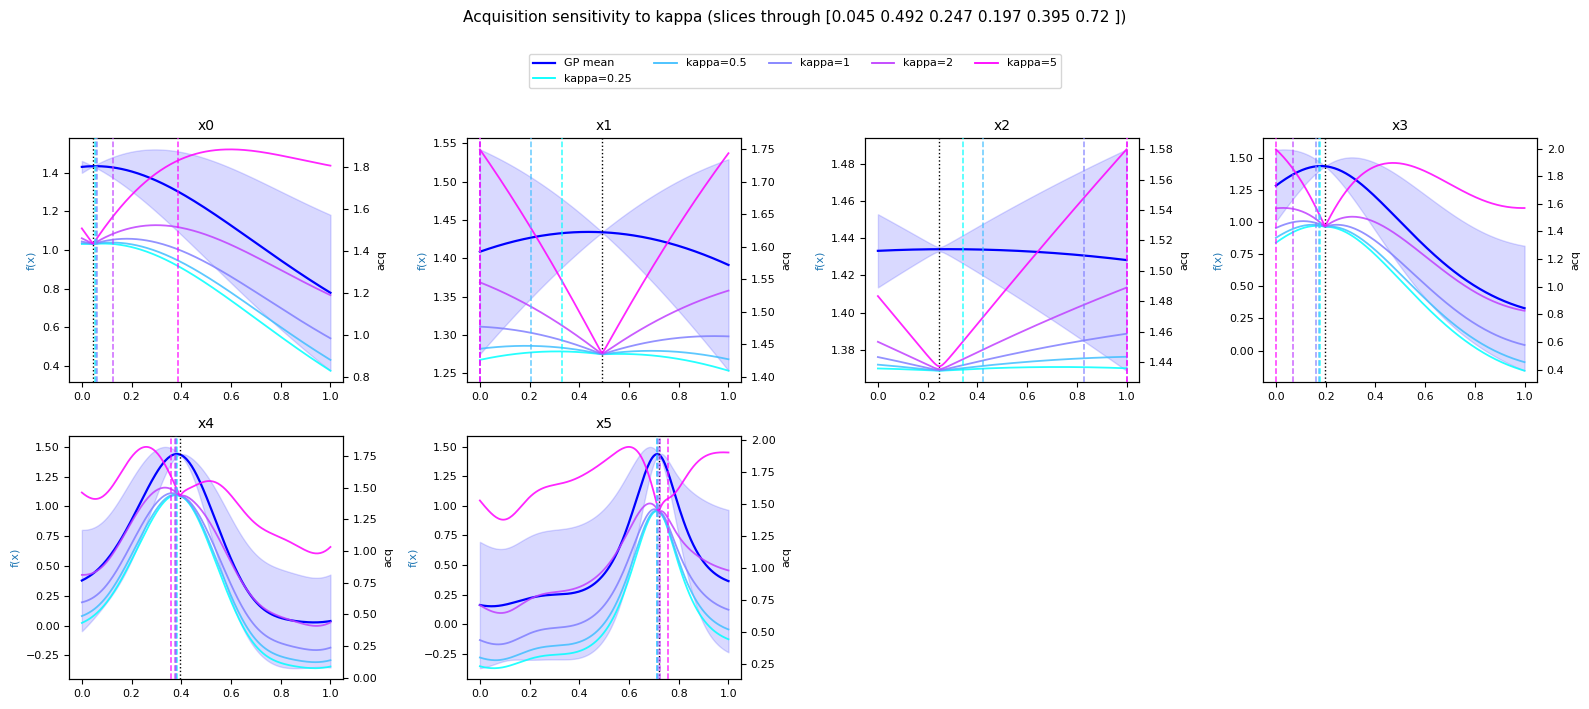


=== restricted to the live axes x[0, 3, 4, 5] (what the choice is made from) ===
 kappa |  pred mean |  pred std |    UPPER bnd |    lower bnd |    dist
     0 |   +1.44321 |   0.01077 |         none |         none |  0.0206
  0.25 |   +1.44168 |   0.02113 |         none |         none |  0.0374
   0.5 |   +1.43578 |   0.03681 |         none |         none |  0.0616
     1 |   +1.41194 |   0.06862 |         none |         none |  0.1074
     2 |   +1.32235 |   0.12870 |         none |         none |  0.1882
incumbent y = 1.434055

using kappa = 0.5, searching only x[0, 3, 4, 5]
predicted mean +1.43578 vs incumbent 1.434055 -> gain +0.00172 (std 0.03681)


In [38]:
def bound_report(p):
    """Report which coordinates sit on a domain edge, upper and lower separately.

    Bounds are the true domain [0,1], so NEITHER edge is automatically a defect
    -- contact means the constrained optimum is on the boundary, which on a
    monotone axis is exactly right. I judge it per axis against that axis's
    monotone direction (see the axis cell), not by which edge it is.
    """
    upper = [d for d in range(D) if np.isclose(p[d], bounds[d, 1])]
    lower = [d for d in range(D) if np.isclose(p[d], bounds[d, 0])]
    return upper, lower


print("=== unrestricted over all 6 axes (shown to demonstrate the problem) ===")
with fitting("kappa sweep (one shared GP)"):
    kappa_rows = compare_kappa_proposals(X, y, bounds, kappa_values=[0.25, 0.5, 1.0, 2.0, 5.0],
                                          maximize=True, n_restarts=40, random_state=0)

print_kappa_comparison(kappa_rows)
print("\nwhat the unrestricted search does with the FLAT axes"
      f" x{flat} (incumbent has {np.round(incumbent[flat], 4)}):")
for row in kappa_rows:
    print(f"  kappa={row['kappa']:<5g} flat-axis values {np.round(row['x_next'][flat], 4)}"
          f"  <- arbitrary; the acquisition is flat along these")

plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()


def restricted_ucb(kappa, n_starts=80):
    """Maximise UCB over the live axes only, holding flat axes at the incumbent."""
    lo = bounds[live, 0]
    hi = bounds[live, 1]

    def neg(v):
        p = incumbent.copy()
        p[live] = v
        return -ucb_acquisition(normalize(p.reshape(1, -1), bounds), gp_check,
                                 kappa=kappa, maximize=True)[0]

    best_val, best_v = np.inf, None
    rng = np.random.default_rng(0)
    for start in rng.uniform(lo, hi, size=(n_starts, len(live))):
        res = minimize(neg, start, method="L-BFGS-B", bounds=list(zip(lo, hi)))
        if res.fun < best_val:
            best_val, best_v = res.fun, res.x
    p = incumbent.copy()
    p[live] = best_v
    m, s = gp_check.predict(normalize(p.reshape(1, -1), bounds), return_std=True)
    return p, m[0], s[0]


print(f"\n=== restricted to the live axes x{live} (what the choice is made from) ===")
print(f"{'kappa':>6} | {'pred mean':>10} | {'pred std':>9} | {'UPPER bnd':>12}"
      f" | {'lower bnd':>12} | {'dist':>7}")
for k in [0.0, 0.25, 0.5, 1.0, 2.0]:
    p, m, s = restricted_ucb(k)
    up, lo_ = bound_report(p)
    print(f"{k:6g} | {m:+10.5f} | {s:9.5f} | {str(up) if up else 'none':>12}"
          f" | {str(lo_) if lo_ else 'none':>12} | {np.linalg.norm(p - incumbent):7.4f}")
print(f"incumbent y = {y.max():.6f}")

# Bound to one constant so the proposal, the slice plot and the diagnostics
# replay can't drift apart.
#
# Largest kappa in the table above whose predicted mean still beats the
# incumbent -- the criterion also used on functions 6 and 8. Week 5's new
# incumbent means 0, 0.25 and 0.5 all show a gain now; 0.5 is the largest.
# The margin is thin (well inside the predicted std), so read this as a mild
# lean towards more exploration rather than a strong signal.
KAPPA = 0.5
p_k, m_k, s_k = restricted_ucb(KAPPA)
print(f"\nusing kappa = {KAPPA}, searching only x{live}")
print(f"predicted mean {m_k:+.5f} vs incumbent {y.max():.6f}"
      f" -> gain {m_k - y.max():+.5f} (std {s_k:.5f})")

# The verdict cell above reports how the committed setting ranks, which only
# means something if CHOSEN names this KAPPA. Config names follow
# f"ucb_k{kappa:g}", so this is checkable rather than a comment to remember.
_expected = "exploit" if KAPPA == 0 else f"ucb_k{KAPPA:g}"
assert CHOSEN == _expected, (
    f"CHOSEN={CHOSEN!r} does not match the committed KAPPA={KAPPA}"
    f" (expected {_expected!r}). The backtest verdict above refers to a config"
    " this notebook does not use -- fix one or the other."
)


## Propose the next point

Live axes from the restricted UCB search at `kappa = 0.5`; x1/x2 held at the incumbent (flat). Expect a step of about 0.06 from the incumbent — larger than a pure exploit step, but still local. The surrogate is well calibrated there (LOO z = +1.0), so this nudges further along the axes that carry signal rather than chasing an unexplained peak.

In [39]:
x_next, mu_next, sigma_next = restricted_ucb(KAPPA, n_starts=150)
gp = gp_check

print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu_next:.6f}, predicted std: {sigma_next:.6f}")
print(f"current best observed y: {y.max():.6f}"
      f"  -> predicted improvement: {mu_next - y.max():+.6f}")
print(f"flat axes x{flat} held at the incumbent:"
      f" {np.allclose(x_next[flat], incumbent[flat])}")

# Bounds are the TRUE DOMAIN, so neither edge is automatically a defect. The
# question is whether the axis is monotone toward that edge (expected) or not
# (worth questioning).
up, lo = bound_report(x_next)
for label, dims, is_upper in (("UPPER", up, True), ("lower", lo, False)):
    print(f"\non the {label} domain edge:", dims or "none")
    for d in dims:
        toward = (srho[d] > 0) == is_upper
        if abs(srho[d]) > 0.4 and toward:
            print(f"  x{d}: EXPECTED -- monotone (spearman {srho[d]:+.3f}) with its"
                  " best end at this edge")
        else:
            print(f"  x{d}: QUESTION IT -- spearman {srho[d]:+.3f} does not point this"
                  " way, so the edge may be the optimiser stopping, not an optimum")

outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("outside the observed range on its own axis:", outside or "none")
if hull is not None:
    print(f"inside the convex hull: {bool(hull.find_simplex(x_next) >= 0)}"
          "  (nearly vacuous at D=6 -- see above)")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.6f}")
print("for comparison, the week-2 proposal was"
      f" {np.linalg.norm(new_X[0] - X_initial[np.argmax(y_initial)]):.4f} from the"
      " then-incumbent and returned the worst y on record; the week-3 proposal"
      f" was {np.linalg.norm(new_X[-1] - X_initial[np.argmax(y_initial)]):.4f}"
      " away and returned the best")
print("\nnearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+.6f}  X={np.round(X[i], 3)}")

--- Next point to evaluate (bounds shape (6, 2)) ---
x_next: [0.086784 0.491672 0.247422 0.155339 0.378564 0.717258]
0.717**2 * Matern(length_scale=[0.959, 2.84, 10, 0.461, 0.212, 0.128], nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: 1.435777, predicted std: 0.036808
current best observed y: 1.434055  -> predicted improvement: +0.001722
flat axes x[1, 2] held at the incumbent: True

on the UPPER domain edge: none

on the lower domain edge: none
outside the observed range on its own axis: none
inside the convex hull: False  (nearly vacuous at D=6 -- see above)

distance from the incumbent: 0.061643
for comparison, the week-2 proposal was 1.8343 from the then-incumbent and returned the worst y on record; the week-3 proposal was 0.0373 away and returned the best

nearest 3 observations to x_next:
  dist=0.0616  y=+1.434055  X=[0.045 0.492 0.247 0.197 0.395 0.72 ]
  dist=0.0820  y=+1.364968  X=[0.058 0.492 0.247 0.218 0.42  0.731]
  dist=0.1092  y=+1.374343  X=[0.004 0.492 0.

## Visualise the GP and acquisition function via 1D slices

Each panel holds the other five dimensions at the current best observed point and sweeps one. Dotted line is the fixed centre, dashed red is `x_next`, green is UCB.

I expect the **x1 and x2 panels to be essentially flat lines** — their range is about 0.005 against roughly 1.2–1.3 for the other four. That flatness is the model, not a plotting bug, and it is exactly why those two coordinates are pinned at the incumbent rather than optimised.

The x0, x3, x4 and x5 panels should each show structure on a comparable scale, which is why I search all four rather than reducing to one axis.

A partial view: the GP along each axis near the best point, not interactions between dimensions.

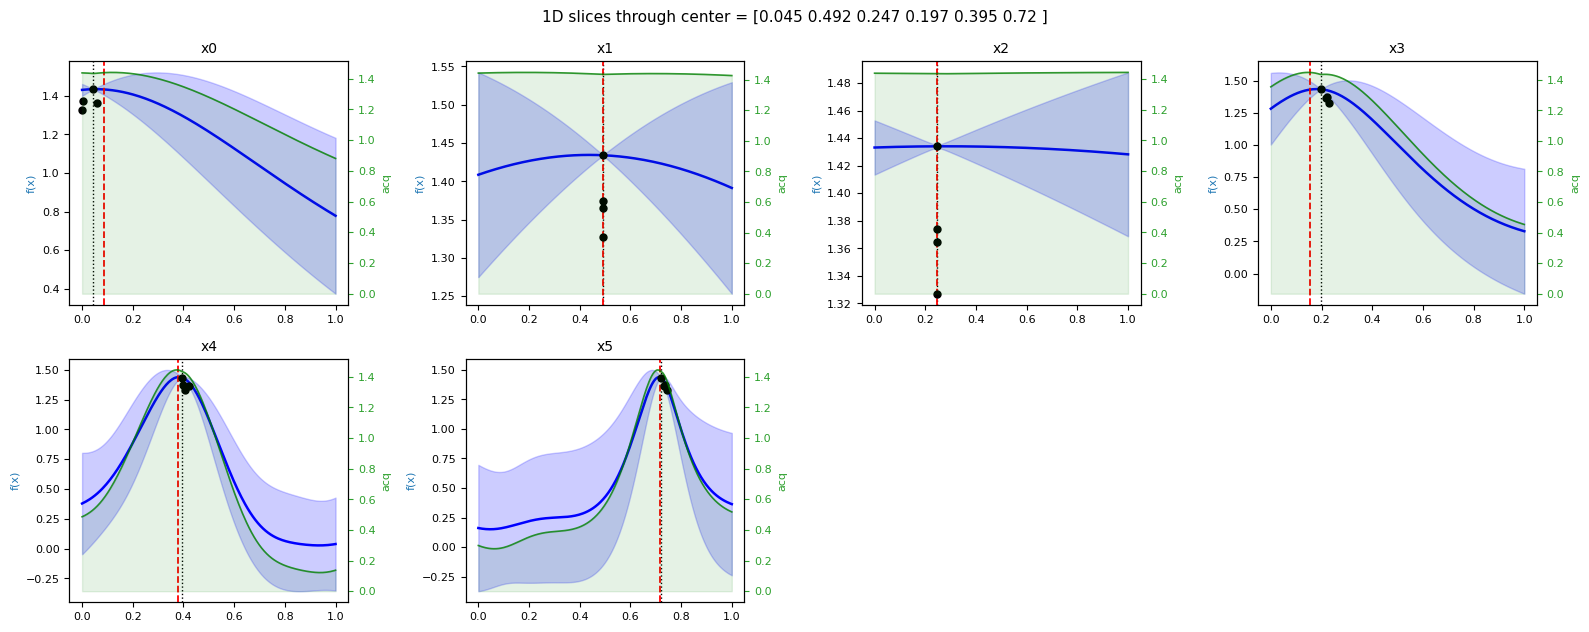

In [40]:
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate: leave-one-out calibration

Refits once per observation, holding it out and predicting it from the rest. At D=6 this is my main way to judge the surrogate.

**This cell used to carry the opposite conclusion and it is worth recording why.** It said the worst-predicted point "should be the incumbent", held out at roughly `0.203 ± 0.086` against a true `1.365` — a ~13.5 sigma miss — and used that to argue the peak rested on a single unexplainable measurement. On current data the incumbent predicts `+1.3324 ± 0.0409` against `1.3743`, so **z = +1.0**, and the worst-predicted point is index 3 — an initial-batch point, at −4.5 sigma. So the cell now reports which point is actually worst rather than asserting which one it ought to be.

Coverage is 29/33 inside their own 95% interval, reasonable at this sample size.

`random_state` is pinned here, and that matters more than it looks. `gp_kwargs` is forwarded to `fit_gp` on every one of the 33 refits, so unseeded this cell was not reproducible — two consecutive runs gave 29/33 with the worst point at index 7 (−2.5σ) and 28/33 with index 3 (−4.5σ). A claim about *which* point is worst is meaningless unless it is seeded.

[fitting: leave-one-out calibration] 76 warnings held back, 5 distinct:
    34 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
    24 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    14 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 5) pinned at upper bound 10.0


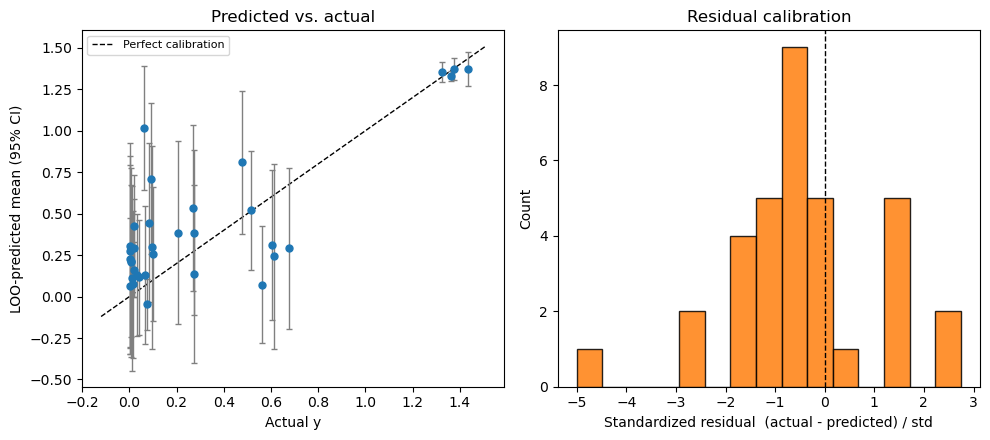

points inside their own 95% LOO interval: 29/34
worst-predicted: index 3 -> true 0.061424, predicted 1.014856 (std 0.190649) = -5.0 sigma
is that the incumbent (the best observation)? False
that point comes from the initial batch


In [41]:
# random_state is pinned. Without it this cell was not reproducible: gp_kwargs
# goes to fit_gp for every refit, so 33 unseeded multi-restart optimisations gave
# a different answer each run -- two consecutive runs reported 29/33 with the
# worst point at index 7 (-2.5 sigma) and 28/33 with index 3 (-4.5 sigma). The
# markdown states which point is worst, so that number has to be stable.
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(
        X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20, "random_state": 0})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")
worst = int(np.argmax(np.abs(y - pred_mean)))
print(f"worst-predicted: index {worst} -> true {y[worst]:.6f},"
      f" predicted {pred_mean[worst]:.6f} (std {pred_std[worst]:.6f})"
      f" = {(y[worst] - pred_mean[worst]) / pred_std[worst]:+.1f} sigma")
# Report WHICH row it is rather than testing `worst == n_initial`, which only
# ever asked about week 2 and quietly stopped meaning anything once there were
# three collected rows.
print("is that the incumbent (the best observation)?", worst == int(np.argmax(y)))
_src = ("the initial batch" if worst < n_initial
        else f"collected week {worst - n_initial + 2}")
print(f"that point comes from {_src}")


## Iteration diagnostics

Replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters and domain-wide uncertainty were at each past proposal. No persisted log involved.

**I have to lower `domain_grid_n` at this dimensionality.** Its `domain_mean_std` field averages posterior std over a `domain_grid_n ** D` grid, so the default 40 means `40**6 = 4.1e9` points — roughly **197 GB**, which kills the kernel outright. The cell sizes the grid so the count stays near 200,000 whatever `D` is, giving 7 here. `domain_mean_std` is therefore coarse: fine for comparing iterations within this run, not comparable against a run that used a different grid.

Two caveats. The `kappa` comes from `KAPPA` so it cannot drift from what the proposal used, but my history is **mixed** — week 2 came from the original template's settings and weeks 3–4 from `ucb`/`kappa=0.25`, none of them from the committed `kappa=0`. `compute_iteration_diagnostics` applies one setting across the whole replay, so the `acq_value` column is an artefact of that mismatch rather than a property of any point. The GP-hyperparameter and `domain_mean_std` columns don't depend on the acquisition and are fine throughout.

`plot_bo_diagnostics` is skipped, since it hard-codes a 2D scatter panel. The trend plots below are dimension-agnostic and gated on having at least three completed iterations.

domain_grid_n = 7 -> 117,649 grid points (the default 40 would be 4,096,000,000)
[fitting: iteration-diagnostics replay] 9 warnings held back, 3 distinct:
     4 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     4 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06

Best y so far: 1.4340545413124588
completed iterations in the modelling set: 4

CAVEAT: my history is MIXED -- week 2 came from the original template's
settings and weeks 3-4 from ucb/kappa=0.25, none of them from the committed
kappa=0.5. compute_iteration_diagnostics applies ONE setting across the whole
replay, so acq_value is an artefact of that mismatch rather than a property of
any point. The GP-hyperparameter and domain_mean_std columns don't depend on
the acquisition and are fine throughout.


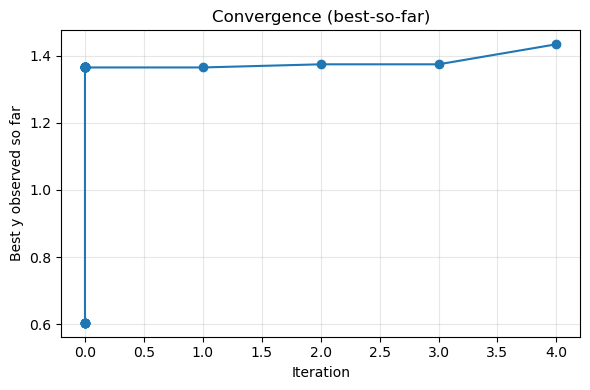

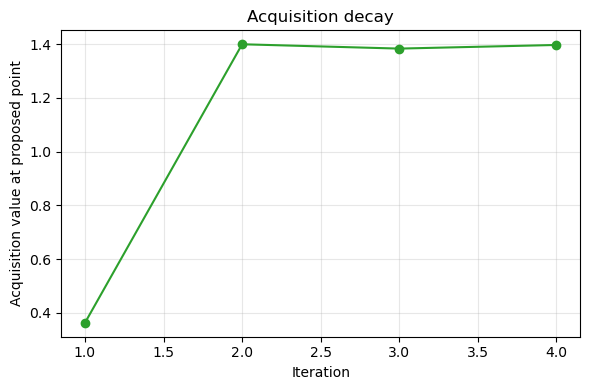

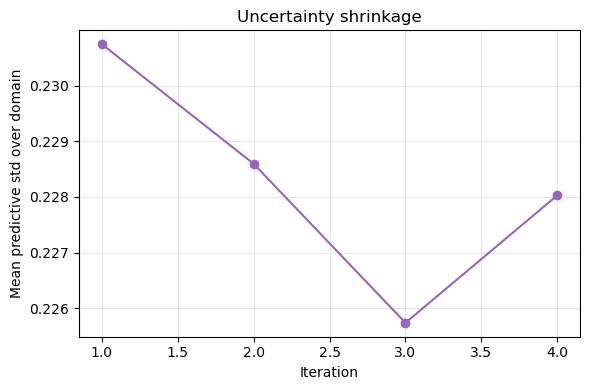

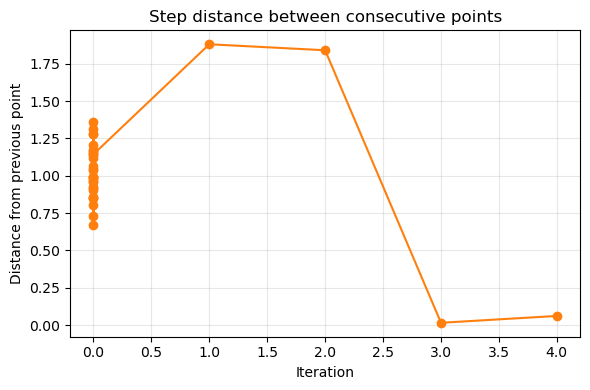

In [42]:
# compute_iteration_diagnostics builds a domain_grid_n ** D grid. The default 40
# is 40**6 = 4.1e9 points (~197 GB) at D=6 and WILL kill the kernel. Size it so
# the grid stays near 200k points whatever D is.
DOMAIN_GRID_N = max(3, int(200_000 ** (1.0 / D)))
print(f"domain_grid_n = {DOMAIN_GRID_N} -> {DOMAIN_GRID_N ** D:,} grid points"
      f" (the default 40 would be {40 ** D:,})")

# The count comes from the MODELLING set rather than len(new_y), so it stays
# correct if I ever exclude rows from the fit.
n_replayed = len(y) - n_initial

with fitting("iteration-diagnostics replay"):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="ucb", kappa=KAPPA,
                                            maximize=True,
                                            domain_grid_n=DOMAIN_GRID_N)

print("\nBest y so far:", np.nanmax(history["y"]))
print("completed iterations in the modelling set:", n_replayed)
print(f"\nCAVEAT: my history is MIXED -- week 2 came from the original template's")
print("settings and weeks 3-4 from ucb/kappa=0.25, none of them from the committed")
print(f"kappa={KAPPA}. compute_iteration_diagnostics applies ONE setting across the whole")
print("replay, so acq_value is an artefact of that mismatch rather than a property of")
print("any point. The GP-hyperparameter and domain_mean_std columns don't depend on")
print("the acquisition and are fine throughout.")

if n_replayed >= 3:
    for plot_fn in (plot_convergence, plot_acquisition_decay,
                    plot_uncertainty_shrinkage, plot_step_distance):
        plot_fn(history)
        plt.show()
else:
    print(f"\nOnly {n_replayed} replayed iteration(s) -- need at least 3 before the")
    print("trend plots say anything. Skipping them; the raw fields are below.")

## Raw diagnostic fields

In [43]:
print("y:", np.round(history["y"], 6))
print("\niteration:", history["iteration"])
print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
print("\npred_mean at proposal time:", history["pred_mean"])
print("\ndomain_mean_std:", history["domain_mean_std"])

y: [6.044330e-01 5.627530e-01 7.503000e-03 6.142400e-02 2.730470e-01
 8.374700e-02 1.364968e+00 9.264500e-02 1.787000e-02 3.356500e-02
 7.351600e-02 2.063100e-01 8.826000e-03 2.684000e-01 6.115260e-01
 1.479800e-02 2.748930e-01 6.676300e-02 4.211800e-02 2.701000e-03
 1.820900e-02 7.016000e-03 1.005070e-01 4.753960e-01 6.751420e-01
 5.164570e-01 3.777000e-03 3.134000e-03 2.134300e-02 9.541100e-02
 3.090000e-04 1.374343e+00 1.327096e+00 1.434055e+00]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 2. 3. 4.]

acq_value (NaN = initial batch; see the caveat above): [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
 0.36354269 1.39960156 1.3834908  1.397

In [44]:
# My proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision too. I submit the 6-dp string; the store keeps 6 dp as well,
# which is what actually gets evaluated.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.086784-0.491672-0.247422-0.155339-0.378564-0.717258

full precision (use for next week's new_X):
0.08678429620110811-0.491672-0.247422-0.15533877004714125-0.3785639787634632-0.7172575869255663


In [45]:
# I record this week's proposal in the weekly store. This rewrites inputs.csv
# rather than appending, so re-running the notebook cannot double-record. I
# submit the 6-dp string printed above -- it is the same value written here.
save_proposal(7, new_X, x_next)


wrote weekly_data/function_7/inputs.csv: 5 row(s) (4 resulted + 1 proposal)
  proposal row: 0.08678429620110811-0.491672-0.247422-0.15533877004714125-0.3785639787634632-0.7172575869255663


'weekly_data/function_7/inputs.csv'